# Live Coding Bab 4 - Preprocessing Data

Nama: Hassan Nashrallah

NIM: 245150200111025

Dataset yang digunakan adalah Diabetes Dataset. Dataset ini berisi informasi medis dari pasien, seperti kadar glukosa, tekanan darah, insulin, BMI, dll. Beberapa nilai dalam dataset ini mengandung missing values yang perlu ditangani. Selain itu, terdapat outlier yang perlu dideteksi dan dilakukan normalisasi data agar memiliki skala yang seragam.

## Langkah 1: Import Library & Dataset

In [7]:
# Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# from google.colab import files

# # Unggah file
# uploaded = files.upload()

In [9]:
# Baca dataset dan tampilkan 5 baris pertama
data = pd.read_csv(r'C:\Users\hassa\OneDrive\Dokumen\praktikumz\kal-praktikum\data\diabetes.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,0,33.6,0.627,50,diabetic
1,85,66,0,26.6,0.351,31,not diabetic
2,183,64,0,23.3,0.672,32,diabetic
3,89,66,94,28.1,0.167,21,not diabetic
4,137,40,168,43.1,2.288,33,diabetic


## Langkah 2: Cek Missing Values
Pada dataset ini, missing values direpresentasikan dengan angka 0, yang tidak masuk akal untuk beberapa fitur medis.

In [10]:
kondisi1 = data['Glucose'] == 0
kondisi2 = data['BloodPressure'] == 0
kondisi3 = data['Insulin'] == 0
kondisi4 = data['BMI'] == 0

data.loc[kondisi1 | kondisi2 | kondisi3 | kondisi4]

,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,0,33.6,0.627,50,diabetic
1,85,66,0,26.6,0.351,31,not diabetic
2,183,64,0,23.3,0.672,32,diabetic
5,116,74,0,25.6,0.201,30,not diabetic
7,115,0,0,35.3,0.134,29,not diabetic
...,...,...,...,...,...,...,...
761,170,74,0,44.0,0.403,43,diabetic
762,89,62,0,22.5,0.142,33,not diabetic
764,122,70,0,36.8,0.340,27,not diabetic
766,126,60,0,30.1,0.349,47,diabetic


## Langkah 3: Ganti Missing Values dengan Mean
Gantilah nilai 0 dengan mean dari setiap kolom

In [11]:
data = data.replace(0, np.nan)

def change_missing_values(df):
  list_kolom = df.columns
  class_kolom = list_kolom[-1]
  for kolom in list_kolom[:-1]:
    df[kolom] = df[kolom].fillna(df.groupby(class_kolom)[kolom].transform('mean'))
  return df

data_imputasi = change_missing_values(data)
data_imputasi.isna().any()

Glucose                     False
BloodPressure               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

## Langkah 4: Deteksi dan Hapus Outlier Menggunakan IQR

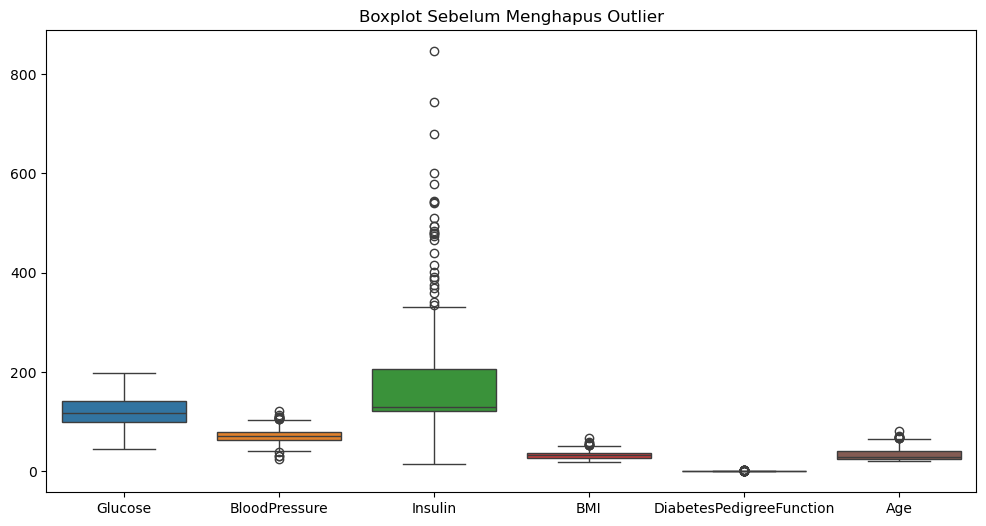

In [12]:
# Boxplot sebelum menghapus outlier
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_imputasi)
plt.title('Boxplot Sebelum Menghapus Outlier')
plt.show()

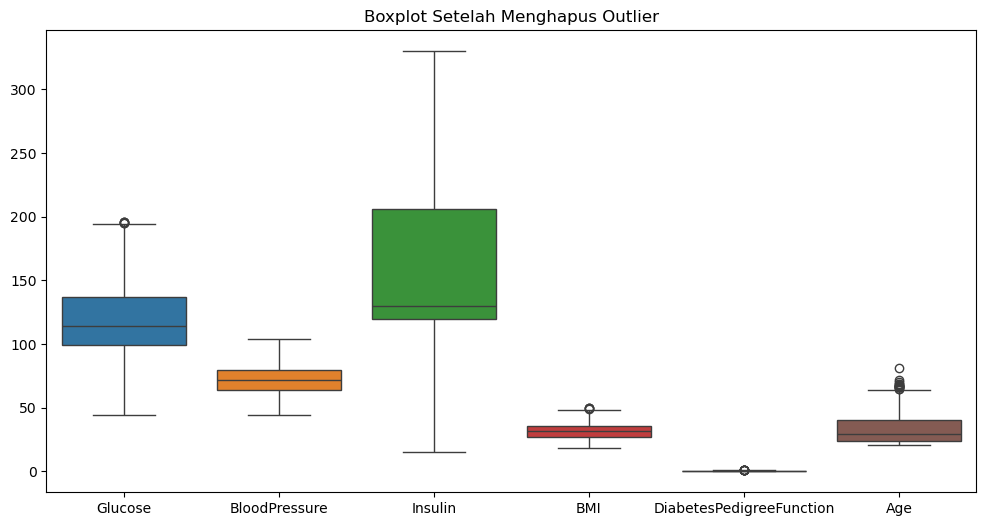

In [13]:
# Fungsi untuk mendeteksi dan menghapus outlier dengan IQR
kolom_outlier = ['Insulin', 'BMI', 'BloodPressure', 'Glucose', 'DiabetesPedigreeFunction']

def remove_outliers(df):
  for kolom in kolom_outlier:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[kolom] >= lower_bound) & (df[kolom] <= upper_bound)]

  return df

data_bersih = remove_outliers(data_imputasi)
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_bersih)
plt.title('Boxplot Setelah Menghapus Outlier')
plt.show()

## Langkah 5: Lakukan Normalisasi Minmax/Z-Score

In [14]:
# Lakukan normalisasi (kecuali kolom 'Outcome')
kolom_normalisasi = data_bersih.columns[:-1]

def normalisasi(df):
  df_copy = df.copy()
  for kolom in kolom_normalisasi:
    mean = df[kolom].mean()
    std = df[kolom].std()

    df_copy[kolom] = (df[kolom] - mean) / std

  return df_copy

data_normal = normalisasi(data_bersih)
data_normal.head()

,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.993325,-0.013768,1.081406,0.254592,0.826534,1.441809,diabetic
1,-1.182483,-0.569929,-0.236042,-0.838156,-0.301285,-0.177355,not diabetic
2,2.202107,-0.755316,1.081406,-1.353309,1.010417,-0.092135,diabetic
3,-1.044336,-0.569929,-0.860499,-0.603996,-1.053163,-1.029546,not diabetic
5,-0.111847,0.171618,-0.236042,-0.994263,-0.914229,-0.262574,not diabetic


## Langkah 6: Label Encoding untuk Target 'Outcome'

In [15]:
def label_encoding(x):
  if 'not' in x:
    return 0
  else:
    return 1

data_normal['Outcome'] = data_normal['Outcome'].apply(lambda x: label_encoding(x))
data_normal.head()

,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.993325,-0.013768,1.081406,0.254592,0.826534,1.441809,1
1,-1.182483,-0.569929,-0.236042,-0.838156,-0.301285,-0.177355,0
2,2.202107,-0.755316,1.081406,-1.353309,1.010417,-0.092135,1
3,-1.044336,-0.569929,-0.860499,-0.603996,-1.053163,-1.029546,0
5,-0.111847,0.171618,-0.236042,-0.994263,-0.914229,-0.262574,0


## Kesimpulan

Pre-processing data dilakukan untuk menghilangkan data bermasalah yang tidak dapat langsung digunakan untuk machine learning. Pre-processing data dimulai dari mencari data bernilai 0 lalu mengubahnya menjadi NaN agar dapat dideteksi sebagai missing value. Setelah itu, data dengan missing value diganti dengan rata-rata dari setiap kolom. Teknik ini disebut imputasi data. Kemudian, outlier atau pencilan data dicari dan dihapus dengan IQR. Terakhir, dilakukan normalisasi data dan label encoding. Dengan demikian, data tersebut sudah siap untuk digunakan untuk machine learing.